In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
dev_path='Dev_data_to_be_shared.csv'
df=pd.read_csv(dev_path)

In [4]:
df.head(5)

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['account_number', 'bad_flag', 'onus_attribute_1',
       'transaction_attribute_1', 'transaction_attribute_2',
       'transaction_attribute_3', 'transaction_attribute_4',
       'transaction_attribute_5', 'transaction_attribute_6',
       'transaction_attribute_7',
       ...
       'bureau_enquiry_47', 'bureau_enquiry_48', 'bureau_enquiry_49',
       'bureau_enquiry_50', 'onus_attribute_43', 'onus_attribute_44',
       'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47',
       'onus_attribute_48'],
      dtype='object', length=1216)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96806 entries, 0 to 96805
Columns: 1216 entries, account_number to onus_attribute_48
dtypes: float64(1189), int64(27)
memory usage: 898.1 MB


In [7]:
df.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
count,96806.000000,96806.000000,7.157500e+04,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,...,94212.0,94212.000000,94212.000000,94212.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000
mean,48403.500000,0.014173,1.542391e+05,9.570769,0.002207,4.092854,77.306435,0.006315,67.043550,0.081034,...,0.0,0.189657,0.044283,7.800673,0.588114,1.497158,0.545650,1.430491,0.121447,0.119208
std,27945.629417,0.118203,1.729925e+05,1513.967595,0.119240,301.580599,3164.987013,0.129545,2516.330899,14.203615,...,0.0,0.597298,0.369451,8.655149,1.059613,1.702795,1.055865,1.728950,0.601256,0.599697
min,1.000000,0.000000,2.500000e+04,0.000000,0.000000,0.000000,-109800.476600,0.000000,-3498.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,5.900000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,48403.500000,0.000000,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,72604.750000,0.000000,1.810000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,11.000000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000
max,96806.000000,1.000000,2.800000e+06,398936.791000,25.000000,55000.000000,358986.000000,12.000000,358986.000000,3150.000000,...,0.0,18.000000,14.000000,102.000000,19.000000,38.000000,19.000000,38.000000,15.000000,15.000000


In [8]:
df.isnull().sum()

account_number                 0
bad_flag                       0
onus_attribute_1           25231
transaction_attribute_1    25231
transaction_attribute_2    25231
                           ...  
onus_attribute_44          85196
onus_attribute_45          85196
onus_attribute_46          85196
onus_attribute_47          85196
onus_attribute_48          85196
Length: 1216, dtype: int64

In [9]:
df.fillna(0, inplace=True)
df.isnull().sum()

account_number             0
bad_flag                   0
onus_attribute_1           0
transaction_attribute_1    0
transaction_attribute_2    0
                          ..
onus_attribute_44          0
onus_attribute_45          0
onus_attribute_46          0
onus_attribute_47          0
onus_attribute_48          0
Length: 1216, dtype: int64

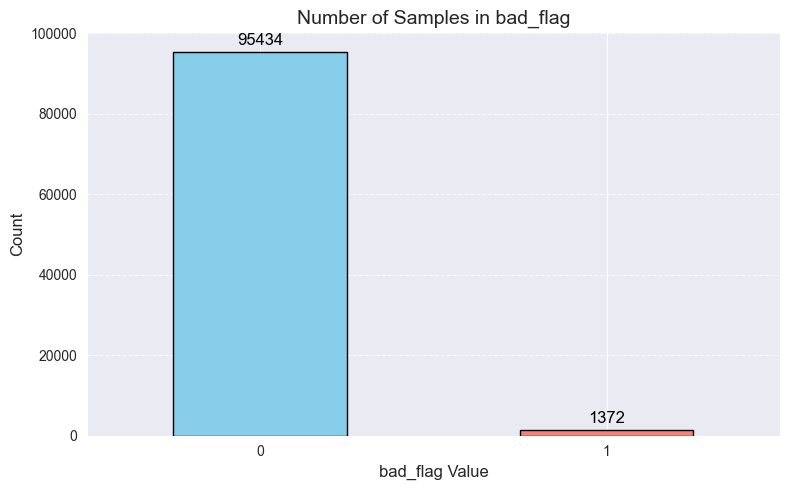

In [10]:
# Count the number of samples for each value in bad_flag
bad_flag_counts = df['bad_flag'].value_counts()

# Plot the counts
plt.figure(figsize=(8, 5))
bars = bad_flag_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

# Add counts on top of the bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate
        height + 0.01 * max(bad_flag_counts),  # Y-coordinate
        f'{int(height)}',  # Text to display
        ha='center', va='bottom', fontsize=12, color='black'
    )

# Customize the plot
plt.title('Number of Samples in bad_flag', fontsize=14)
plt.xlabel('bad_flag Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

In [11]:
selected_cols = [col for col in df.columns if col.startswith(('transaction_attribute', 'bureau', 'bureau_enquiry'))]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Copy the original DataFrame to preserve the original data
df_normalized = df.copy()

# Normalize the selected columns
df_normalized[selected_cols] = scaler.fit_transform(df[selected_cols])

print(f"Normalization completed on the following columns: {selected_cols}")

Normalization completed on the following columns: ['transaction_attribute_1', 'transaction_attribute_2', 'transaction_attribute_3', 'transaction_attribute_4', 'transaction_attribute_5', 'transaction_attribute_6', 'transaction_attribute_7', 'transaction_attribute_8', 'transaction_attribute_9', 'transaction_attribute_10', 'transaction_attribute_11', 'transaction_attribute_12', 'transaction_attribute_13', 'transaction_attribute_14', 'transaction_attribute_15', 'transaction_attribute_16', 'transaction_attribute_17', 'transaction_attribute_18', 'transaction_attribute_19', 'transaction_attribute_20', 'transaction_attribute_21', 'transaction_attribute_22', 'transaction_attribute_23', 'transaction_attribute_24', 'transaction_attribute_25', 'transaction_attribute_26', 'transaction_attribute_27', 'transaction_attribute_28', 'transaction_attribute_29', 'transaction_attribute_30', 'transaction_attribute_31', 'transaction_attribute_32', 'transaction_attribute_33', 'transaction_attribute_34', 'trans

In [12]:
df_normalized.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
count,96806.000000,96806.000000,9.680600e+04,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,...,96806.0,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.00000,96806.000000,96806.000000,96806.000000
mean,48403.500000,0.014173,1.140391e+05,0.000018,0.000065,0.000055,0.234345,0.000389,0.009787,0.000019,...,0.0,0.010254,0.003078,0.074428,0.070533,0.179555,0.06544,0.171560,0.014565,0.014297
std,27945.629417,0.118203,1.634346e+05,0.003263,0.004101,0.004715,0.005806,0.009285,0.005970,0.003877,...,0.0,0.032780,0.026038,0.084616,0.413706,0.764394,0.40635,0.757932,0.211919,0.211253
min,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.0,0.000000,0.000000,0.009804,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,48403.500000,0.000000,6.900000e+04,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.0,0.000000,0.000000,0.049020,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,72604.750000,0.000000,1.450000e+05,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.0,0.000000,0.000000,0.107843,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,96806.000000,1.000000,2.800000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,1.000000,1.000000,1.000000,19.000000,38.000000,19.00000,38.000000,15.000000,15.000000


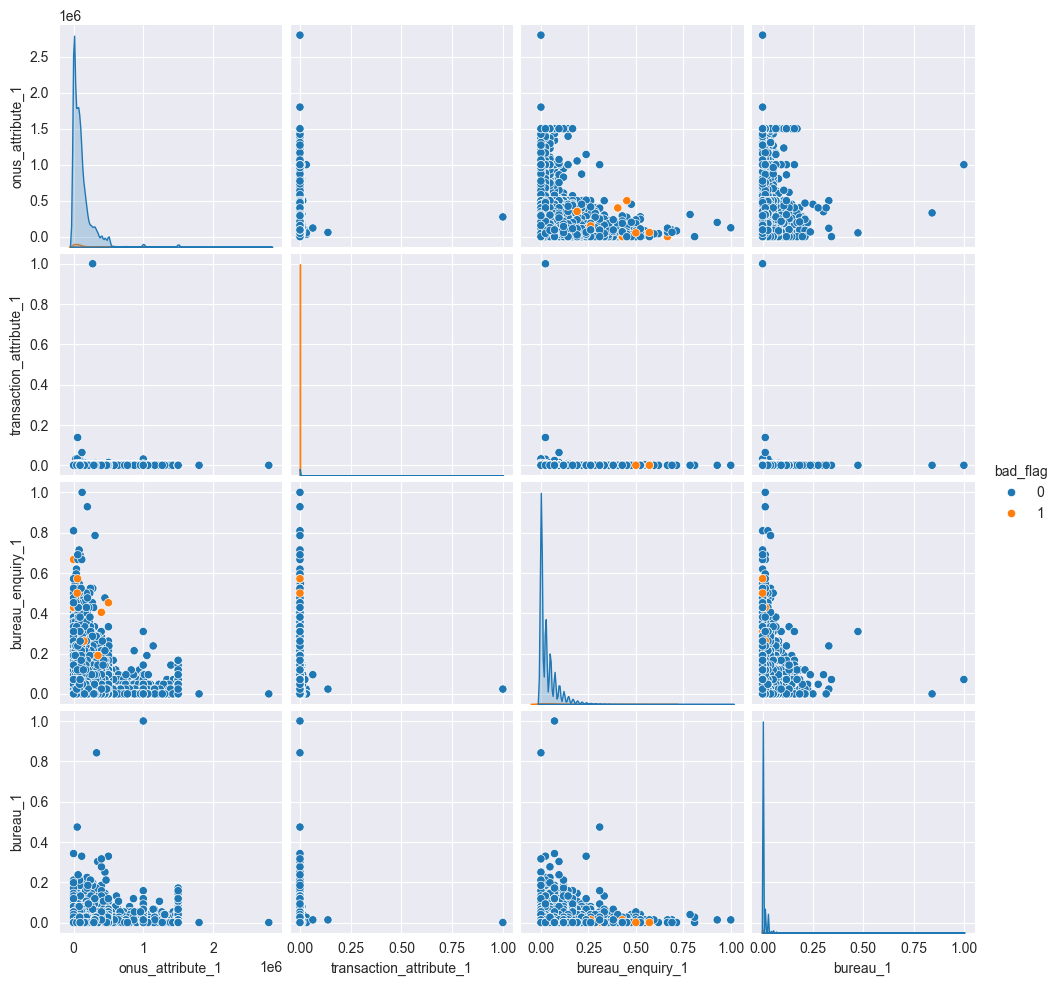

In [13]:
selected_columns = ['onus_attribute_1', 'transaction_attribute_1', 'bureau_enquiry_1', 'bureau_1']

# Create the pairplot
sns.pairplot(df_normalized[selected_columns + ['bad_flag']], hue='bad_flag')

# Show the plot
plt.show()

In [21]:
from imblearn.under_sampling import RandomUnderSampler

# Extract features (X) and target (y) from df_normalized
X = df_normalized.drop(columns=['account_number','bad_flag'])
y = df_normalized['bad_flag']

# Initialize the undersampler
undersampler = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

# Apply undersampling to balance the dataset
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Combine the resampled features and target into a new dataframe
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='bad_flag')], axis=1)

# Check the distribution of the classes in the resampled dataset
print("Resampled class distribution:")
print(df_resampled['bad_flag'].value_counts())


Resampled class distribution:
bad_flag
0    1372
1    1372
Name: count, dtype: int64


In [22]:
X_resampled = df_resampled.drop(columns=['bad_flag'])
y_resampled = df_resampled['bad_flag']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=97)

# Check the shape of the resulting splits
print(f"Training Data Features: {X_train.shape}")
print(f"Testing Data Features: {X_test.shape}")
print(f"Training Data Target: {y_train.shape}")
print(f"Testing Data Target: {y_test.shape}")


Training Data Features: (2195, 1214)
Testing Data Features: (549, 1214)
Training Data Target: (2195,)
Testing Data Target: (549,)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=97, max_iter=2000, class_weight='balanced')

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (1)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))



Accuracy Score: 0.7012750455373407

Confusion Matrix:
[[200  70]
 [ 94 185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.74      0.71       270
           1       0.73      0.66      0.69       279

    accuracy                           0.70       549
   macro avg       0.70      0.70      0.70       549
weighted avg       0.70      0.70      0.70       549


ROC-AUC Score: 0.7761051373954599


C:\Users\sharv\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


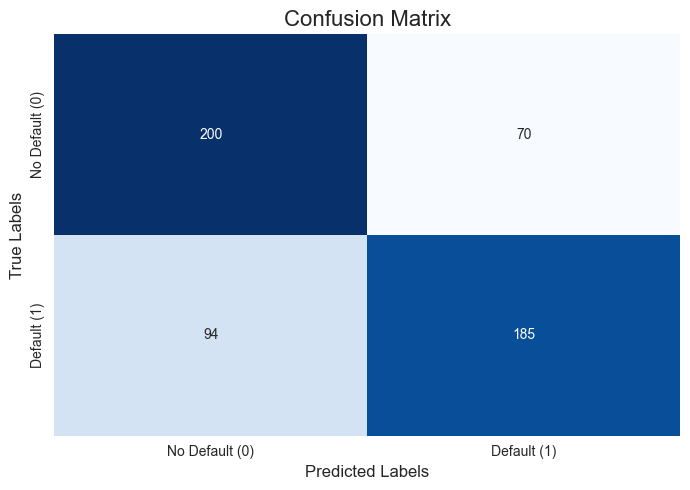

In [24]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()

plt.show()